# Assignement : Instructor Effectiveness Analysis and Modeling
Predicting effectiveness of instructor using batch-level data -> High, Medium, Low

## 1. Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/atifmazhar/assign/instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")
print(f"Shape : {df.shape}")
df.head()

Shape : (2000, 12)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [4]:
# Check total unique Instructors, Courses, Batches
print("Instructors:", df["instructor_id"].nunique())
print("Courses:", df["course_id"].nunique())
print("Batches:", df["batch_id"].nunique())

Instructors: 120
Courses: 25
Batches: 2000


In [5]:
# Missing Value
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [6]:
# Check Duplicates
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [7]:
# Check for Batch ID duplicate row
print("Duplicate batch IDs:", df["batch_id"].duplicated().sum())

Duplicate batch IDs: 0


In [8]:
# Check Data Types
df.dtypes

batch_id                       object
instructor_id                  object
course_id                      object
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object

In [9]:
# Basic Statictics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


In [10]:
## Let's try to understand how many batches average teach by a instructor
batches_per_instructor = df.groupby("instructor_id").size()
batches_per_instructor[:10], batches_per_instructor[:90:-1]

(instructor_id
 I_001    25
 I_002    20
 I_003    18
 I_004    17
 I_005    19
 I_006    15
 I_007    15
 I_008    20
 I_009    18
 I_010    13
 dtype: int64,
 instructor_id
 I_120    13
 I_119    19
 I_118    19
 I_117    19
 I_116    17
 I_115    18
 I_114    13
 I_113    26
 I_112    13
 I_111    22
 I_110    10
 I_109    23
 I_108    21
 I_107    14
 I_106    11
 I_105    16
 I_104    19
 I_103    18
 I_102     7
 I_101    27
 I_100    13
 I_099    26
 I_098    15
 I_097    18
 I_096    17
 I_095    17
 I_094    19
 I_093    17
 I_092    26
 dtype: int64)

In [11]:
print(batches_per_instructor.describe())

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
dtype: float64


In [12]:
## Course Distribution -> batches_per_courses
batches_per_course = df.groupby("course_id").size()

print(batches_per_course.describe())

count    25.000000
mean     80.000000
std       7.205322
min      64.000000
25%      77.000000
50%      81.000000
75%      85.000000
max      91.000000
dtype: float64


In [13]:
## Let's select numerical features
metrics = df.select_dtypes(
    include = ["int64","float64"]
).columns
metrics

Index(['completion_rate', 'avg_score_improvement', 'avg_quiz_score',
       'dropout_rate', 'avg_watch_time', 'assignment_submission_rate',
       'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

In [14]:
df[metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


In [15]:
## Check Possible Capping
# Several metrics appear to be capped at their boundaries. Let's see
for col in metrics:
    print(col)
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print()

completion_rate
Min: 0.3
Max: 0.98

avg_score_improvement
Min: 6.159239501
Max: 40.0

avg_quiz_score
Min: 40.38672466
Max: 100.0

dropout_rate
Min: 0.02
Max: 0.7

avg_watch_time
Min: 0.2874399043
Max: 1.0

assignment_submission_rate
Min: 0.2511108037
Max: 1.0

forum_activity_rate
Min: 0.0
Max: 0.6411111441

avg_feedback_score
Min: 2.639914572
Max: 5.0

feedback_response_rate
Min: 0.2599352423
Max: 1.0



In [16]:
bounded = {
    "completion_rate": 0.30,
    "dropout_rate": 0.70,
    "avg_watch_time": 1.00,
    "assignment_submission_rate": 1.00,
    "avg_feedback_score": 5.00,
    "feedback_response_rate": 1.00
}

for col, value in bounded.items():
    count = (df[col] == value).sum()
    print(col, ":", count, "observations at boundary")

completion_rate : 77 observations at boundary
dropout_rate : 72 observations at boundary
avg_watch_time : 149 observations at boundary
assignment_submission_rate : 125 observations at boundary
avg_feedback_score : 67 observations at boundary
feedback_response_rate : 94 observations at boundary


In [17]:
## Let's see correlation matrix
df[metrics].corr().round(2)

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
completion_rate,1.00,0.40,0.33,-0.95,0.19,0.22,0.21,0.32,0.28
avg_score_improvement,0.40,1.00,0.22,-0.38,0.13,0.13,0.15,0.19,0.20
avg_quiz_score,0.33,0.22,1.00,-0.32,0.11,0.12,0.13,0.15,0.14
dropout_rate,-0.95,-0.38,-0.32,1.00,-0.17,-0.21,-0.20,-0.30,-0.27
avg_watch_time,0.19,0.13,0.11,-0.17,1.00,0.08,0.09,0.12,0.14
assignment_submission_rate,0.22,0.13,0.12,-0.21,0.08,1.00,0.07,0.07,0.08
forum_activity_rate,0.21,0.15,0.13,-0.20,0.09,0.07,1.00,0.15,0.13
avg_feedback_score,0.32,0.19,0.15,-0.30,0.12,0.07,0.15,1.00,0.12
feedback_response_rate,0.28,0.20,0.14,-0.27,0.14,0.08,0.13,0.12,1.00


## Data Understanding Conclusion

- Data has 2000 rows and 12 columns.
- There are 120 instructors and 25 courses.
- There are no missing values or duplicate batch IDs.
- The data contains metrics related to performance, engagement and feedback.
- Completion rate and dropout rate are strongly related, so we should be careful not to count the same information twice.
- Some values are at the minimum or maximum limits, so a few metrics may be capped.
- The data looks good enough to continue with instructor-level analysis and effectiveness score creation.

## 2. Exploratory Data Analysis
Let's first examine the distributions and relationships between
the main performance, engagement, and feedback metrics.

Visualize, Visualize, Visualize !

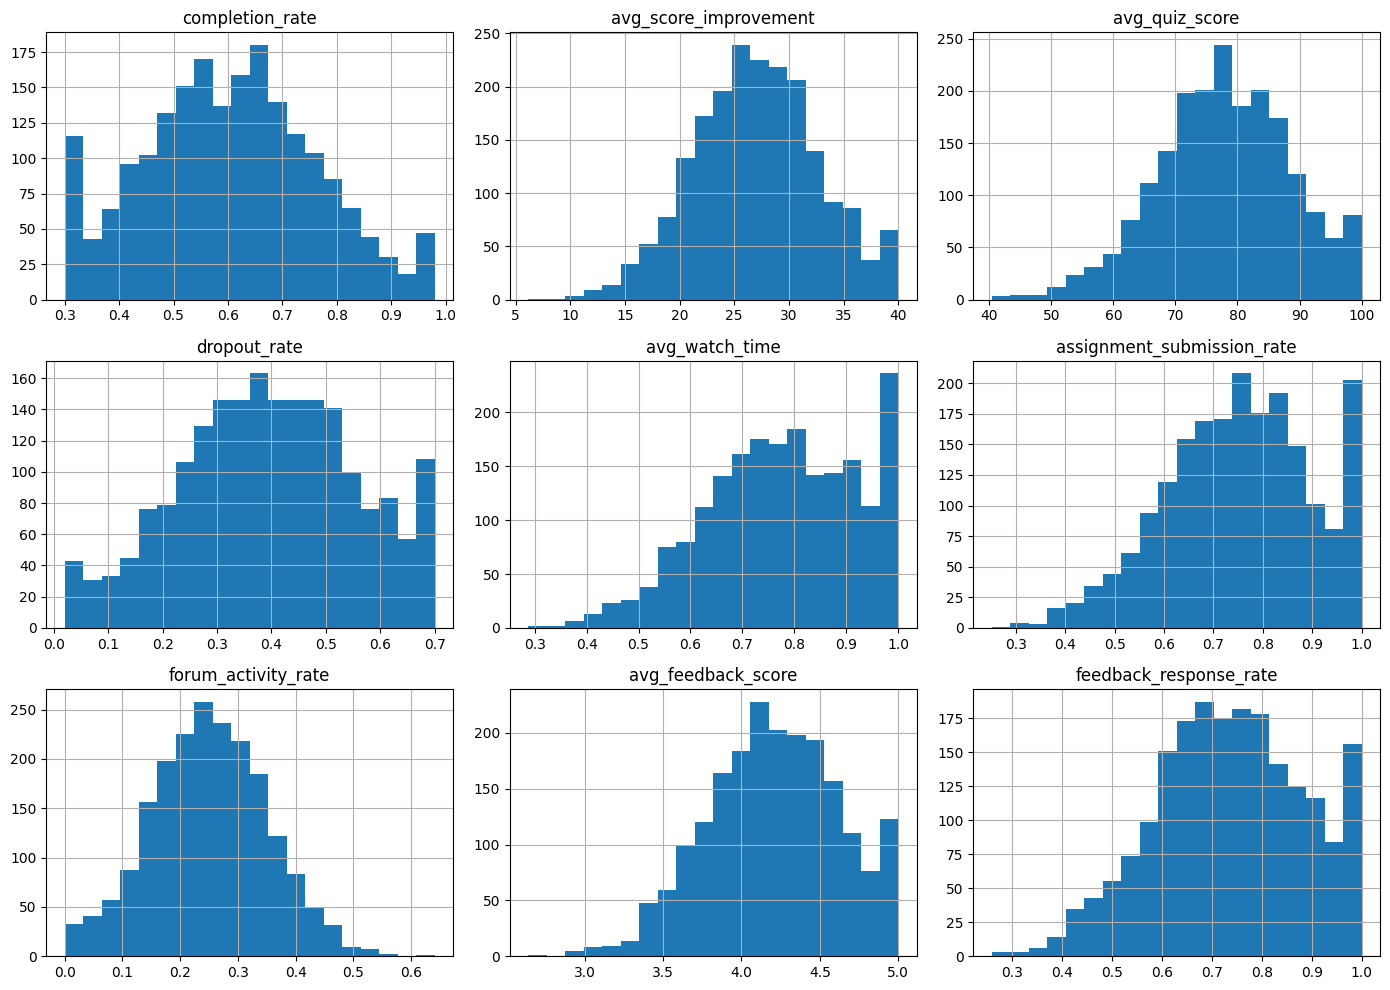

In [18]:
### 2.1 Numerical Distributions
df[metrics].hist(figsize=(14,10),bins = 20)
plt.tight_layout()
plt.show()

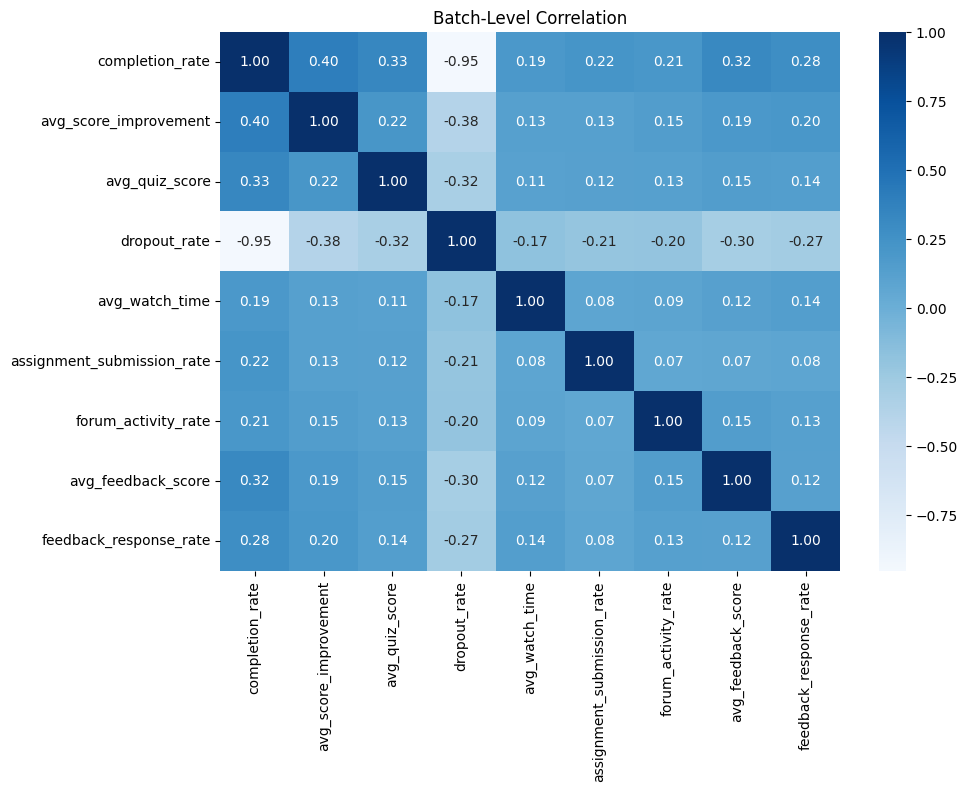

In [19]:
### 2.2 Visualize Batch-level Correlation
batch_corr = df[metrics].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(batch_corr, annot=True, fmt=".2f", cmap="Blues", center=0)
plt.title("Batch-Level Correlation")
plt.show()

### Observations

- Completion rate and dropout rate have a very strong negative correlation (-0.95)-> Too much negativity between them.
- Completion rate and score improvement have a moderate positive correlation (0.40).
- Completion rate and quiz score also have a positive relationship (0.33).
- Score improvement and dropout rate have a moderate negative correlation (-0.38).
- Most engagement and feedback variables have weak positive correlations with completion rate.
- Overall, completion rate is related to many performance metrics, while most other variables have weaker relationships with each other.
- Completion rate and dropout rate contain very similar information, so be careful.

In [20]:
### 2.3 Create Instructor-Level Data
instructor = df.groupby("instructor_id")[metrics].mean()

instructor.head()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
instructor_id,,,,,,,,,
I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858
I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338
I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132
I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460
I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197


In [21]:
print("Instructor-level rows:", len(instructor))

Instructor-level rows: 120


In [22]:
instructor.max()

completion_rate                0.940783
avg_score_improvement         34.856747
avg_quiz_score                91.071769
dropout_rate                   0.664304
avg_watch_time                 0.903739
assignment_submission_rate     0.924766
forum_activity_rate            0.343266
avg_feedback_score             4.641986
feedback_response_rate         0.891873
dtype: float64

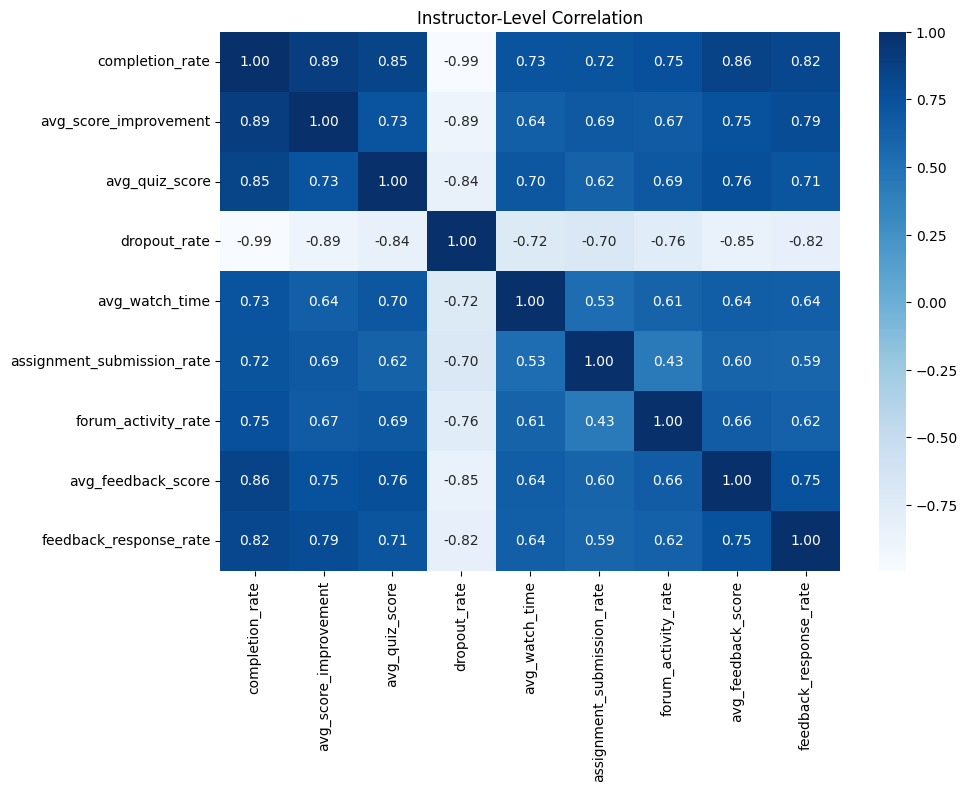

In [23]:
### 2.4 Instructor-Level Correlation
instructor_corr = instructor.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    instructor_corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0
)

plt.title("Instructor-Level Correlation")
plt.show()

### Observation 
1. Correlation seems strong now on instructor level interesting.
2. This means, instructor level differences are more persistent than batch level so, it will help much to calculate effectiveness. 
3. So, mostly going to help measuring overall instructor effectiveness.


In [24]:
### 2.5 Completion vs Dropout
print(
    "Correlation:",
    round(instructor["completion_rate"].corr(
            instructor["dropout_rate"]),
        3)
)

Correlation: -0.994


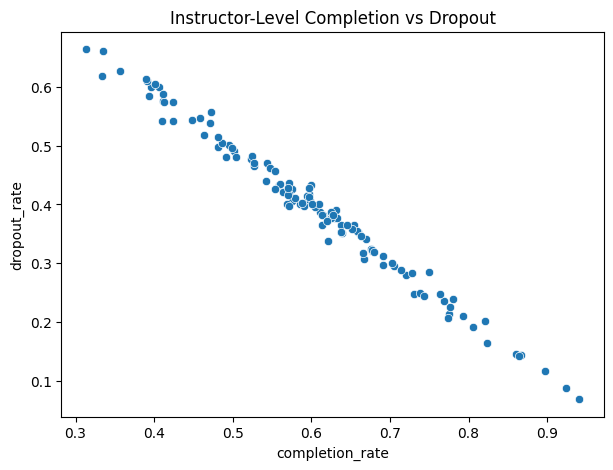

In [25]:
### Visualize now
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=instructor,
    x="completion_rate",
    y="dropout_rate"
)

plt.title("Instructor-Level Completion vs Dropout")
plt.show()

### Observation

Completion rate and dropout rate are almost mirror measures
at the instructor level. `(Negative Correlation)`

Using both in the primary effectiveness score would give
similar information twice.-> `Need to Avoid Redundancy`

Therefore, dropout will be retained as a diagnostic variable only,
while completion will represent the outcome domain.

In [26]:
### 2.6 Instructor vs Course Variation
for col in metrics:
    instructor_std = df.groupby("instructor_id")[col].mean().std()
    course_std = df.groupby("course_id")[col].mean().std()

    print(col,"Instructor:", round(instructor_std, 3),
        "Course:", round(course_std, 3))

completion_rate Instructor: 0.132 Course: 0.02
avg_score_improvement Instructor: 3.263 Course: 0.729
avg_quiz_score Instructor: 5.203 Course: 1.109
dropout_rate Instructor: 0.128 Course: 0.02
avg_watch_time Instructor: 0.049 Course: 0.017
assignment_submission_rate Instructor: 0.059 Course: 0.015
forum_activity_rate Instructor: 0.038 Course: 0.01
avg_feedback_score Instructor: 0.185 Course: 0.056
feedback_response_rate Instructor: 0.062 Course: 0.015


### Observation

Instructor-level variation is substantially larger than
course-level variation for most metrics.

This indicates that instructor differences explain an important
part of the observed variation.
However, course differences are not zero, so course context
should still be considered when defining the effectiveness score.

In [27]:
### 2.7 Course Means
course_means = df.groupby("course_id")[metrics].mean()

course_means.describe().T[["min", "max", "mean", "std"]]

,min,max,mean,std
completion_rate,0.561902,0.639422,0.602505,0.019950
avg_score_improvement,25.687680,28.445458,27.028293,0.728665
avg_quiz_score,76.146757,80.611406,77.933435,1.109300
dropout_rate,0.354628,0.444770,0.394937,0.020494
avg_watch_time,0.742057,0.802179,0.776299,0.016761
assignment_submission_rate,0.714003,0.775479,0.752766,0.014620
forum_activity_rate,0.235184,0.267160,0.250152,0.010249
avg_feedback_score,4.104935,4.315455,4.206205,0.055690
feedback_response_rate,0.708496,0.763959,0.736772,0.014923


In [28]:
### 2.8 Normalize Metrics Within Course 
normalized = df.copy()

for col in metrics:
    mean = df.groupby("course_id")[col].transform("mean")
    std = df.groupby("course_id")[col].transform("std")

    normalized[col] = (df[col] - mean) / std
normalized[metrics].head()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,-2.050322,-2.352949,-0.424992,1.796206,-0.204904,0.252060,-1.441601,-0.983664,-1.623920
1,0.226590,-0.742300,-0.151389,0.308875,-2.297797,1.617722,0.268704,1.579577,-0.155532
2,-1.785994,-1.824426,0.217353,1.730931,1.489053,0.375924,-0.602287,-1.599192,-0.223491
3,0.087758,-0.460284,2.057243,-0.272818,0.502269,-1.461684,0.506349,0.038667,1.800632
4,-0.299508,0.889296,2.293841,0.597364,0.981136,0.721733,-0.053144,0.299926,-0.119123


In [29]:
### Instructor-Level -> PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(instructor[metrics])


pca = PCA()
pca.fit(X)

PCA()

In [30]:
print("Variance explained by PC1:",
    round(pca.explained_variance_ratio_[0] * 100, 2),
    "%")

Variance explained by PC1: 75.97 %


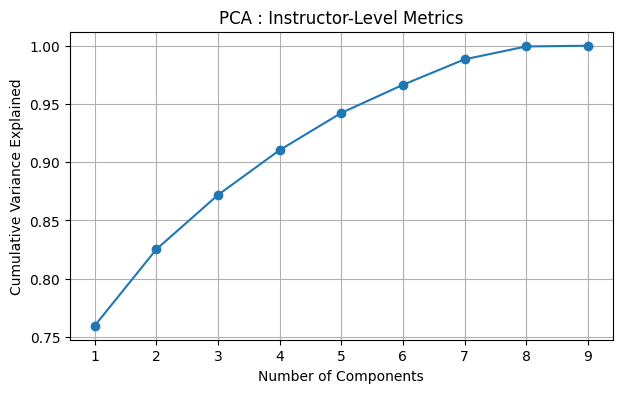

In [31]:
### 2.10 PCA Variance Plot
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA : Instructor-Level Metrics")
plt.grid()
plt.show()

In [32]:
# 2.11 PCA Loadings
loadings = pd.Series(
    pca.components_[0],
    index=metrics
).sort_values()

loadings

dropout_rate                 -0.372578
assignment_submission_rate    0.285221
avg_watch_time                0.302505
forum_activity_rate           0.302901
feedback_response_rate        0.330691
avg_feedback_score            0.336977
avg_quiz_score                0.338372
avg_score_improvement         0.345597
completion_rate               0.373810
dtype: float64

In [33]:
### 2.12 Create Simple Latent Score
latent = instructor.copy()

for col in metrics:
    latent[col] = (
        latent[col] - latent[col].mean()
    ) / latent[col].std()

latent["dropout_rate"] = -latent["dropout_rate"]

latent_score = latent.mean(axis=1)

pc1 = pd.Series(
    pca.transform(X)[:, 0],
    index=instructor.index
)

print(
    "Correlation with PCA:",
    round(latent_score.corr(pc1), 3)
)

Correlation with PCA: 1.0


### Latent Structure Finding
`Relationship is extremely strong`.

A single instructor-level latent dimension explains most of
the variation across the metrics.

A simple standardized composite is also almost perfectly
aligned with the first PCA component.

This suggests that many observed metrics are different
manifestations of a common underlying instructor-level factor.

This is supporting evidence, not proof of a true unobserved
"teaching quality" variable.(Noted)

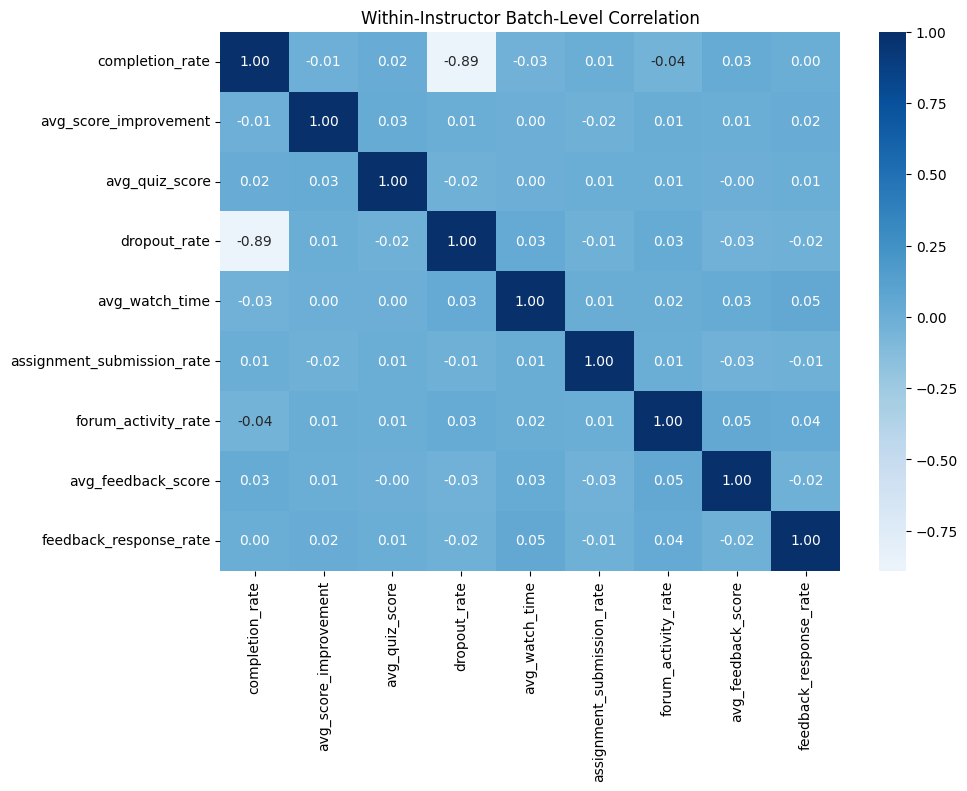

In [34]:
### 2.13 Check Within-Instructor Variation
within = df[metrics] - df.groupby("instructor_id")[metrics].transform("mean")

within_corr = within.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    within_corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0
)

plt.title("Within-Instructor Batch-Level Correlation")
plt.show()

### Observation

After removing each instructor's average level, most
cross-metric relationships become much weaker. (`Interesting Finding`)

This suggests that much of the strong correlation observed
at instructor level comes from persistent differences between
instructors rather than every metric moving together within
each individual instructor's batches.

## EDA Summary

1. The dataset contains bounded and capped metrics.
2. Batch-level relationships are weaker than instructor-level
   relationships.
3. Instructor-level aggregation reveals strong relationships
   across outcomes, engagement, and feedback.
4. Completion and dropout contain highly overlapping information.
5. Instructor-level variation is larger than course-level
   variation for most metrics.
6. Course differences still exist, so course normalization is
   considered as a robustness step.
7. PCA shows a strong common latent structure at instructor level.
8. The latent structure should be treated as supporting evidence,
   not as ground-truth teaching quality.

## 3. Define Instructor Effectiveness


### 3.1 Effectiveness Score

We divide the metrics into three groups:

1. Outcomes
2. Engagement
3. Feedback

Completion is used instead of dropout because the two metrics
contain highly overlapping information.

In [35]:
outcome = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score"
]

engagement = [
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate"
]

feedback = [
    "avg_feedback_score",
    "feedback_response_rate"
]

In [36]:
### 3.2 Normalize Within Course
df2 = df.copy()

all_metrics = outcome + engagement + feedback

for col in all_metrics:
    mean = df.groupby("course_id")[col].transform("mean")
    std = df.groupby("course_id")[col].transform("std")
    
    df2[col] = (df[col] - mean) / std

In [37]:
### 3.3 Create Domain Scores

# Outcomes
df2["outcome_score"] = (
    df2[outcome].sum(axis=1) / len(outcome)
)

# Engagement
df2["engagement_score"] = (
    df2[engagement].sum(axis=1) / len(engagement)
)

# Feedback
df2["feedback_score"] = (
    df2[feedback].sum(axis=1) / len(feedback)
)

In [38]:
### 3.4 Final Batch Effectiveness Score
df2["effectiveness"] = (
    0.50 * df2["outcome_score"]
    + 0.30 * df2["engagement_score"]
    + 0.20 * df2["feedback_score"]
)
df2["effectiveness"].describe()



count    2.000000e+03
mean    -2.664535e-17
std      5.384739e-01
min     -1.981613e+00
25%     -3.716044e-01
50%      1.632040e-02
75%      3.691865e-01
max      1.538399e+00
Name: effectiveness, dtype: float64

In [39]:
df2[
    [
        "outcome_score",
        "engagement_score",
        "feedback_score",
        "effectiveness"
    ]
].head()

,outcome_score,engagement_score,feedback_score,effectiveness
0,-1.609421,-0.464815,-1.303792,-1.204914
1,-0.222366,-0.137124,0.712023,-0.009916
2,-1.131022,0.420897,-0.911342,-0.621511
3,0.561572,-0.151022,0.919650,0.419409
4,0.961210,0.549908,0.090402,0.663658


In [40]:
### 3.6 Aggregate Batch → Instructor
instructor = df2.groupby("instructor_id").agg({
    "effectiveness": "mean",
    "outcome_score": "mean",
    "engagement_score": "mean",
    "feedback_score": "mean",
    "completion_rate": "mean",
    "avg_score_improvement": "mean",
    "avg_quiz_score": "mean",
    "avg_watch_time": "mean",
    "assignment_submission_rate": "mean",
    "forum_activity_rate": "mean",
    "avg_feedback_score": "mean",
    "feedback_response_rate": "mean",
    "dropout_rate": "mean"
})
instructor.head()

,effectiveness,outcome_score,engagement_score,feedback_score,completion_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,dropout_rate
instructor_id,,,,,,,,,,,,,
I_001,-0.099839,-0.075850,-0.116570,-0.134718,-0.338888,-0.026043,0.137381,-0.078609,-0.186320,-0.084780,-0.005739,-0.263697,0.470593
I_002,0.416299,0.526470,0.314092,0.294179,0.740245,0.527255,0.311911,0.425932,0.075443,0.440901,0.303406,0.284952,0.247194
I_003,0.503636,0.613993,0.291119,0.546521,0.970880,0.502636,0.368462,0.239549,0.183082,0.450727,0.588151,0.504891,0.234828
I_004,-0.316723,-0.536605,-0.045064,-0.174508,-0.856481,-0.719149,-0.034185,0.094116,0.029590,-0.258898,-0.279953,-0.069062,0.547261
I_005,0.774598,1.083823,0.683020,0.138903,1.587159,0.958979,0.705331,0.455730,0.809400,0.783929,-0.001916,0.279721,0.145733


In [41]:
### 3.7 Let's see how much data each instructor has
n_batches = df.groupby("instructor_id")["batch_id"].nunique()
n_courses = df.groupby("instructor_id")["course_id"].nunique()

instructor["n_batches"] = n_batches
instructor["n_courses"] = n_courses

instructor[
    ["effectiveness", "n_batches", "n_courses"]
].head()

,effectiveness,n_batches,n_courses
instructor_id,,,
I_001,-0.099839,25,16
I_002,0.416299,20,10
I_003,0.503636,18,14
I_004,-0.316723,17,10
I_005,0.774598,19,13


### Handling Different Numbers of Batches

Instructors have different numbers of observed batches. I used the mean to represent
typical instructor performance and also kept the number of batches as a context variable.

The dataset does not contain instructors with extremely few batches, so no instructor was
removed. However, instructors with more batches have more stable averages, which should
be considered when interpreting the results.

In [42]:
### 3.8 Create Effectiveness Tiers
instructor["tier"] = pd.qcut(
    instructor["effectiveness"],
    3,
    labels=["Low", "Medium", "High"]
)
print(instructor["tier"].value_counts())

tier
Low       40
Medium    40
High      40
Name: count, dtype: int64


In [43]:
### 3.9 The Final Instructor Table
instructor[
    [
        "effectiveness",
        "outcome_score",
        "engagement_score",
        "feedback_score",
        "n_batches",
        "n_courses",
        "tier"
    ]
].sort_values("effectiveness")

,effectiveness,outcome_score,engagement_score,feedback_score,n_batches,n_courses,tier
instructor_id,,,,,,,
I_044,-1.151601,-1.476002,-0.676240,-1.053640,15,12,Low
I_075,-1.109403,-1.404270,-0.830550,-0.790518,19,14,Low
I_050,-0.998105,-1.221878,-0.732935,-0.836428,12,8,Low
I_113,-0.845105,-1.085934,-0.458995,-0.822196,26,16,Low
I_074,-0.782923,-0.983147,-0.500137,-0.706542,17,12,Low
...,...,...,...,...,...,...,...
I_091,0.786068,1.142869,0.387826,0.491430,8,7,High
I_105,0.955656,1.244565,0.645926,0.697979,16,12,High
I_018,0.967809,1.213637,0.751368,0.677900,14,11,High


In [44]:
### 3.10 Check Whether Tiers Make Sense

instructor.groupby("tier", observed=True)["effectiveness"].mean()

tier
Low      -0.478826
Medium   -0.004743
High      0.474457
Name: effectiveness, dtype: float64

In [47]:
instructor.groupby("tier", observed=True)[
    ["outcome_score", "engagement_score", "feedback_score"]
].mean()

,outcome_score,engagement_score,feedback_score
tier,,,
Low,-0.631270,-0.282831,-0.391710
Medium,0.014857,-0.023022,-0.026322
High,0.611722,0.297191,0.397195


In [48]:
instructor.groupby("tier", observed=True)[
    ["outcome_score", "engagement_score", "feedback_score"]
].mean()

,outcome_score,engagement_score,feedback_score
tier,,,
Low,-0.631270,-0.282831,-0.391710
Medium,0.014857,-0.023022,-0.026322
High,0.611722,0.297191,0.397195


In [49]:
### 3.11 Check Completion and Dropout

instructor.groupby("tier", observed=True)["dropout_rate"].mean()

tier
Low       0.528786
Medium    0.393569
High      0.262315
Name: dropout_rate, dtype: float64

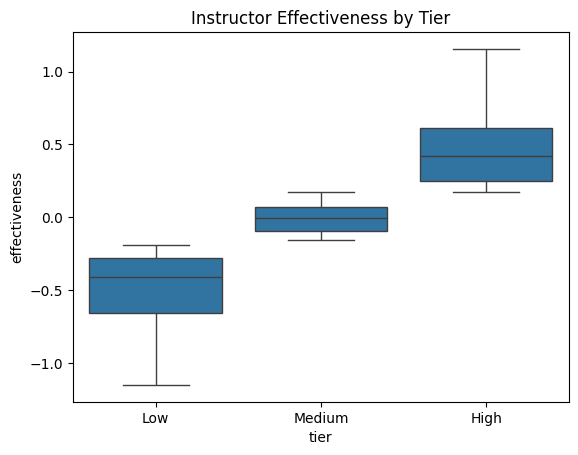

In [50]:
sns.boxplot(
    data=instructor,
    x="tier",
    y="effectiveness"
)

plt.title("Instructor Effectiveness by Tier")
plt.show()

## Effectiveness Definition

The effectiveness score is an operational measure created for
this analysis. It is not ground-truth teaching quality.

The score gives more importance to student outcomes, followed by
engagement and feedback.

Completion and dropout are highly correlated, so both are not
included in the primary score.

Course-level normalization is used so that instructors are
compared relative to the courses they teach.

The final score is aggregated from batches to instructors.

Low, Medium, and High are relative tiers based on the instructor
score distribution.

## 4.Robustness Checks
Let's check whether our assumption of effectiveness is stable or not

In [51]:
### Raw vs Course-Normalized Score
raw = df.groupby("instructor_id")[metrics].mean()

raw_score = raw[outcome].mean(axis=1) * 0.5
raw_score += raw[engagement].mean(axis=1) * 0.3
raw_score += raw[feedback].mean(axis=1) * 0.2

print("Correlation:", round(raw_score.corr(instructor["effectiveness"]), 3))
print("Rank correlation:", round(raw_score.corr(
    instructor["effectiveness"], method="spearman"), 3))

Correlation: 0.969
Rank correlation: 0.958


In [52]:
### 4.2 Batch-Weighted vs Course-Balanced
course_score = df2.groupby(
    ["instructor_id", "course_id"]
)["effectiveness"].mean()

balanced = course_score.groupby(level=0).mean()

print("Correlation:", round(
    balanced.corr(instructor["effectiveness"]), 3
))

Correlation: 0.998


In [53]:
### 4.3 PCA vs Our Score -> Strong measure
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

x = StandardScaler().fit_transform(instructor[metrics])

pc1 = PCA(1).fit_transform(x).ravel()

print("PCA correlation:", round(
    np.corrcoef(instructor["effectiveness"], pc1)[0, 1], 3
))

PCA correlation: 0.998


In [54]:
### 4.4 Final Stability Check
old = pd.qcut(
    instructor["effectiveness"],
    3,
    labels=["Low", "Medium", "High"]
)

new = pd.qcut(
    raw_score,
    3,
    labels=["Low", "Medium", "High"]
)

print("Same tier:", (old == new).mean())

Same tier: 0.8833333333333333


## Robustness Summary

The effectiveness ranking remains broadly stable under:
- course normalization,
- course-balanced aggregation,
- and comparison with the PCA latent structure.

Therefore, the proposed score provides a reasonable operational
measure for this dataset -> Good for effectiveness

## 5.ML Model
The effectiveness score was created using outcomes + engagement + feedback.
Therefore, using those same variables to predict the tier would mostly reconstruct our formula.

So we make two models:

- `Reference model`: can use target-related variables.
- `Main model`: uses only leading indicators - engagement + feedback.

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

### 5.1 Main Model

In [56]:
features = engagement + feedback

X = instructor[features]
y = instructor["tier"]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [58]:
### Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [59]:
### Evaluate
print("Macro F1:", round(f1_score(y_test, pred, average="macro"), 3))
print(classification_report(y_test, pred))

Macro F1: 0.704
              precision    recall  f1-score   support

        High       0.70      0.88      0.78         8
         Low       0.86      0.75      0.80         8
      Medium       0.57      0.50      0.53         8

    accuracy                           0.71        24
   macro avg       0.71      0.71      0.70        24
weighted avg       0.71      0.71      0.70        24



### 5.2 Try More Model

In [60]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(name)
    print("Macro F1:", round(
        f1_score(y_test, pred, average="macro"), 3
    ))
    print()

Logistic
Macro F1: 0.704

Random Forest
Macro F1: 0.672

Gradient Boosting
Macro F1: 0.717



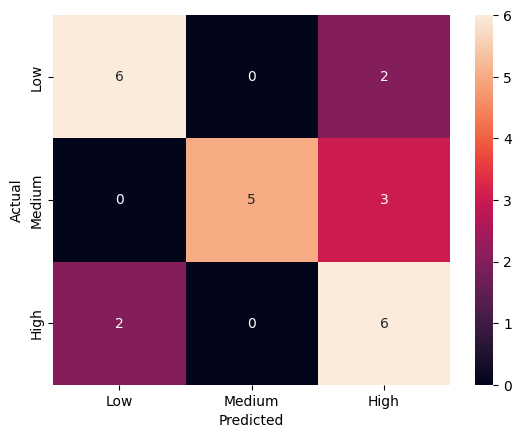

In [61]:
### Visualize - Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 5.3 Reference Model

In [62]:
ref_features = outcome + engagement + feedback

X = instructor[ref_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Reference Macro F1:",
      round(f1_score(y_test, pred, average="macro"), 3))

Reference Macro F1: 0.834


### Leakage Check

The reference model uses variables that helped create the
effectiveness score, so high performance is expected.

It should not be interpreted as evidence that the model can
independently predict true instructor quality.

The main model therefore uses engagement and feedback as
leading indicators and excludes the outcome variables.

### Evaluation Choice

Macro-F1 is used because the target contains three effectiveness classes.
It gives equal importance to Low, Medium, and High classes.

Accuracy alone can hide poor performance on one class, so precision,
recall, and F1-score are also considered.

The tiers are approximately balanced, so there is no major class imbalance.

## ML Summary

- Unit of prediction: instructor
- Number of instructors: 120
- Target: Low / Medium / High effectiveness
- Main predictors: engagement and feedback
- Primary metric: Macro-F1
- Reference model: includes target-related variables
- Main model: excludes outcome variables to reduce leakage

Because the dataset contains only 120 instructors, model
performance should be interpreted cautiously.

### 6. Model Interpretation

In [63]:
### 6.1 Feature Importance
model = GradientBoostingClassifier(random_state=42)

model.fit(X_train, y_train)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

feedback_response_rate        0.451799
completion_rate               0.399489
avg_feedback_score            0.052217
avg_watch_time                0.038531
avg_score_improvement         0.023666
avg_quiz_score                0.019443
forum_activity_rate           0.007493
assignment_submission_rate    0.007362
dtype: float64


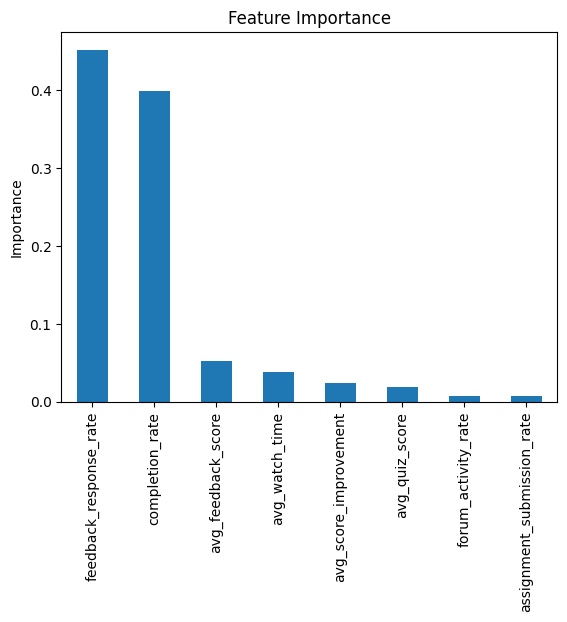

In [64]:
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

In [65]:
### 6.2 Prediction Confidence
prob = model.predict_proba(X_test)

confidence = prob.max(axis=1)

print(pd.Series(confidence).describe())

count    24.000000
mean      0.976641
std       0.072791
min       0.646915
25%       0.991177
50%       0.999840
75%       0.999997
max       0.999998
dtype: float64


In [67]:

pd.DataFrame({
        "actual": y_test.values,
        "predicted": model.predict(X_test),
        "confidence": confidence
    }).sort_values("confidence").head(10)


,actual,predicted,confidence
13,Medium,High,0.646915
18,Medium,Low,0.915524
14,Low,Medium,0.961355
22,High,Medium,0.971698
0,Medium,High,0.976627
8,High,High,0.984708
19,Medium,Medium,0.993333
7,Medium,High,0.994692
6,High,High,0.997470
10,Low,Low,0.998161


## 7. Final Limitations
### Limitations

- The effectiveness score is an operational definition, not
  ground-truth teaching quality.
- The dataset contains only 120 instructors.
- Several metrics are capped at boundaries.
- Feedback may contain response or selection bias.
- Course context can affect observed performance.
- The model predicts the constructed effectiveness tiers,
  not an independent measure of instructor quality.
- Results may change with different time periods or datasets.
- The model should not be used alone for employment, promotion,
  compensation, or disciplinary decisions.


### 1. What defines instructor effectiveness?

Instructor effectiveness is defined using three dimensions:

- Outcomes: 50%
- Engagement: 30%
- Feedback: 20%

The score is an operational measure created for this analysis,
not a ground-truth measure of teaching quality.
                                           


### 2. Why were these metrics selected?

Outcomes represent student performance.

Engagement represents student participation and learning activity.

Feedback represents learner perception and instructor responsiveness.

Completion and dropout are highly correlated, so only completion
is used in the primary effectiveness score to avoid double counting.

### 3. Why aggregate batch data to instructor level?

A single batch can contain considerable variation.

After aggregation, relationships between the metrics become much
stronger, showing that instructor-level differences are more
persistent than individual batch-level variation.

The final analysis therefore uses 120 instructors as the modeling
units.


### 4. Why consider course normalization?

Different courses can have different typical performance levels.

Normalizing within course allows a batch to be compared with
other batches from the same course.

This reduces the risk of treating course differences as
instructor differences.

### 5. Why is dropout not included with completion?

Completion and dropout are almost mirror measures at instructor
level.

Including both would give similar information twice.

Therefore, completion is used in the primary score and dropout
is kept as a diagnostic variable.

### 6. Why are outcome variables excluded from the main ML model?

Outcome variables are part of the effectiveness score used to
create the target.

Using them directly to predict the target would make the model
partly reconstruct the formula used to create the label.

Therefore, the main model uses engagement and feedback as
leading indicators instead.

### 7. What are the main limitations?

- Only 120 instructors are available for modeling.
- The target is constructed rather than externally validated.
- Some metrics are capped.
- Feedback can contain response or selection bias.
- Course context can affect observed results.
- The model predicts the constructed tiers, not true teaching quality.

## 8. Final Executive Summary
## Executive Summary

### 1. Dataset
- **2,000** batch records
- **120** instructors
- **25** courses

### 2. EDA Findings
- Relationships were stronger at the instructor level than at the individual batch level.
- Completion and dropout contained highly overlapping information.
- Therefore, completion was used in the primary score, while dropout was kept as a diagnostic variable.

### 3. Effectiveness Definition
- Instructor effectiveness was calculated using a weighted composite:
  - **50% Outcomes**
  - **30% Engagement**
  - **20% Feedback**
- Metrics were **normalized within course** before calculating the score.
  
### 4. Instructor-Level Aggregation
- Batch-level effectiveness scores were aggregated to the **instructor level**.
- Instructors were divided into three tiers:
  - **Low**
  - **Medium**
  - **High**

### 5. Robustness Checks
- Compared:
  - Raw aggregation
  - Course-balanced aggregation
  - PCA-based structure
- The overall effectiveness structure remained **relatively stable**.

### 6. Machine Learning
- Several classical ML models were compared using **Macro-F1**.

### 7. Prediction Approach
- The main prediction model uses **Engagement and Feedback** as leading indicators.
- Outcome variables used to construct the target were excluded from the main prediction model.
- This helps **reduce circularity**.

### 8. Interpretation
- The target represents an **operational definition of effectiveness**, not ground-truth teaching quality.
- Therefore, the results should be interpreted **cautiously** and should not be treated as definitive measures of instructor quality.

### Q1. Which features most influenced instructor effectiveness?

Feedback score, score improvement, and completion rate are among
the strongest signals.

This is expected because these variables are directly included
in the effectiveness definition.

Therefore, high model importance here shows that the model can
reconstruct our scoring definition; it does not prove causal
drivers of teaching quality.

### Q2. Which variables could be misleading or confounded?

Forum activity and assignment submission can depend on course
policies.

Quiz scores can depend on course difficulty.

Watch time does not necessarily mean active learning.

Feedback response rate can reflect survey participation or
administrative follow-up.

Therefore, these variables should not be interpreted as pure
measures of teaching quality.

### Q3. How could this model fail in real-world usage?

The model could be affected by:

- instructors optimizing for the metrics,
- course difficulty differences,
- feedback-response bias,
- survivorship bias,
- changes in instructor performance over time,
- and the circularity of predicting a target created from the
same underlying features.

### Q4. What additional data would improve the analysis?

Useful additions would include:

- pre-course assessment scores,
- learner prior performance,
- learner demographics,
- instructor experience and qualifications,
- qualitative learner feedback,
- course difficulty information,
- and time-based batch data.


### Q5. Should this model be used for instructor evaluation?

It should be used as a decision-support or early-warning tool,
not as an automated final judgment.

It can help identify instructors who may benefit from coaching
or further review.

It should not be the sole basis for firing, demotion,
compensation, or other high-stakes decisions because the score
is only a proxy and can be affected by course and learner factors.